In [1]:
# Import everything we need
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


In [2]:

# Load YouTube trending data directly
df = pd.read_csv(r'C:\Users\ADMIN\Desktop\DataScience\30-Day-Data-Science-Journey\USvideos.csv', encoding='latin-1')

print("Data loaded successfully!")
print(f"Shape: {df.shape}")
print(df.head())

Data loaded successfully!
Shape: (40949, 16)
      video_id trending_date  \
0  2kyS6SvSYSE      17.14.11   
1  1ZAPwfrtAFY      17.14.11   
2  5qpjK5DgCt4      17.14.11   
3  puqaWrEC7tY      17.14.11   
4  d380meD0W0M      17.14.11   

                                               title          channel_title  \
0                 WE WANT TO TALK ABOUT OUR MARRIAGE           CaseyNeistat   
1  The Trump Presidency: Last Week Tonight with J...        LastWeekTonight   
2  Racist Superman | Rudy Mancuso, King Bach & Le...           Rudy Mancuso   
3                   Nickelback Lyrics: Real or Fake?  Good Mythical Morning   
4                           I Dare You: GOING BALD!?               nigahiga   

   category_id              publish_time  \
0           22  2017-11-13T17:13:01.000Z   
1           24  2017-11-13T07:30:00.000Z   
2           23  2017-11-12T19:05:24.000Z   
3           24  2017-11-13T11:00:04.000Z   
4           24  2017-11-12T18:01:41.000Z   

                      

In [3]:
df.isnull()

,video_id,trending_date,title,channel_title,category_id,publish_time,tags,views,likes,dislikes,comment_count,thumbnail_link,comments_disabled,ratings_disabled,video_error_or_removed,description
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40944,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
40945,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True
40946,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
40947,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [4]:
from warnings import filterwarnings
filterwarnings("ignore")

In [6]:
df.isnull().sum()

video_id                    0
trending_date               0
title                       0
channel_title               0
category_id                 0
publish_time                0
tags                        0
views                       0
likes                       0
dislikes                    0
comment_count               0
thumbnail_link              0
comments_disabled           0
ratings_disabled            0
video_error_or_removed      0
description               570
dtype: int64

In [7]:
# Remove rows with missing values in key columns
df = df.dropna(subset=['views', 'likes', 'dislikes'])

# Convert trending_date to datetime (if it exists)
if 'trending_date' in df.columns:
    df['trending_date'] = pd.to_datetime(df['trending_date'], format='%y.%d.%m', errors='coerce')

# Create engagement rate (likes + dislikes / views)
df['engagement_rate'] = ((df['likes'] + df['dislikes']) / df['views']) * 100

# Create like ratio (likes / total reactions)
df['like_ratio'] = (df['likes'] / (df['likes'] + df['dislikes'])) * 100

print("✅ Data cleaned!")
print(f"📊 Final dataset: {df.shape[0]} videos")
print("\n🎯 New calculated columns:")
print("- engagement_rate: How engaged viewers are")
print("- like_ratio: % of people who liked vs disliked")


✅ Data cleaned!
📊 Final dataset: 40949 videos

🎯 New calculated columns:
- engagement_rate: How engaged viewers are
- like_ratio: % of people who liked vs disliked


In [8]:
df


,video_id,trending_date,title,channel_title,category_id,publish_time,tags,views,likes,dislikes,comment_count,thumbnail_link,comments_disabled,ratings_disabled,video_error_or_removed,description,engagement_rate,like_ratio
0,2kyS6SvSYSE,2017-11-14,WE WANT TO TALK ABOUT OUR MARRIAGE,CaseyNeistat,22,2017-11-13T17:13:01.000Z,SHANtell martin,748374,57527,2966,15954,https://i.ytimg.com/vi/2kyS6SvSYSE/default.jpg,False,False,False,SHANTELL'S CHANNEL - https://www.youtube.com/s...,8.083258,95.096953
1,1ZAPwfrtAFY,2017-11-14,The Trump Presidency: Last Week Tonight with J...,LastWeekTonight,24,2017-11-13T07:30:00.000Z,"last week tonight trump presidency|""last week ...",2418783,97185,6146,12703,https://i.ytimg.com/vi/1ZAPwfrtAFY/default.jpg,False,False,False,"One year after the presidential election, John...",4.272024,94.052124
2,5qpjK5DgCt4,2017-11-14,"Racist Superman | Rudy Mancuso, King Bach & Le...",Rudy Mancuso,23,2017-11-12T19:05:24.000Z,"racist superman|""rudy""|""mancuso""|""king""|""bach""...",3191434,146033,5339,8181,https://i.ytimg.com/vi/5qpjK5DgCt4/default.jpg,False,False,False,WATCH MY PREVIOUS VIDEO â¶ \n\nSUBSCRIBE âº ...,4.743072,96.472928
3,puqaWrEC7tY,2017-11-14,Nickelback Lyrics: Real or Fake?,Good Mythical Morning,24,2017-11-13T11:00:04.000Z,"rhett and link|""gmm""|""good mythical morning""|""...",343168,10172,666,2146,https://i.ytimg.com/vi/puqaWrEC7tY/default.jpg,False,False,False,Today we find out if Link is a Nickelback amat...,3.158220,93.854955
4,d380meD0W0M,2017-11-14,I Dare You: GOING BALD!?,nigahiga,24,2017-11-12T18:01:41.000Z,"ryan|""higa""|""higatv""|""nigahiga""|""i dare you""|""...",2095731,132235,1989,17518,https://i.ytimg.com/vi/d380meD0W0M/default.jpg,False,False,False,I know it's been a while since we did this sho...,6.404639,98.518149
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40944,BZt0qjTWNhw,2018-06-14,The Cat Who Caught the Laser,AaronsAnimals,15,2018-05-18T13:00:04.000Z,"aarons animals|""aarons""|""animals""|""cat""|""cats""...",1685609,38160,1385,2657,https://i.ytimg.com/vi/BZt0qjTWNhw/default.jpg,False,False,False,The Cat Who Caught the Laser - Aaron's Animals,2.346036,96.497661
40945,1h7KV2sjUWY,2018-06-14,True Facts : Ant Mutualism,zefrank1,22,2018-05-18T01:00:06.000Z,[none],1064798,60008,382,3936,https://i.ytimg.com/vi/1h7KV2sjUWY/default.jpg,False,False,False,NaN,5.671498,99.367445
40946,D6Oy4LfoqsU,2018-06-14,I GAVE SAFIYA NYGAARD A PERFECT HAIR MAKEOVER ...,Brad Mondo,24,2018-05-18T17:34:22.000Z,I gave safiya nygaard a perfect hair makeover ...,1066451,48068,1032,3992,https://i.ytimg.com/vi/D6Oy4LfoqsU/default.jpg,False,False,False,I had so much fun transforming Safiyas hair in...,4.604056,97.898167
40947,oV0zkMe1K8s,2018-06-14,How Black Panther Should Have Ended,How It Should Have Ended,1,2018-05-17T17:00:04.000Z,"Black Panther|""HISHE""|""Marvel""|""Infinity War""|...",5660813,192957,2846,13088,https://i.ytimg.com/vi/oV0zkMe1K8s/default.jpg,False,False,False,How Black Panther Should Have EndedWatch More ...,3.458920,98.546498


In [13]:
print("🏆 TOP 10 MOST VIEWED VIDEOS:")
print("="*80)

top_10_views = df.nlargest(10, 'views')[['title', 'channel_title', 'views', 'likes']]
top_10_views
 ##for idx, row in top_10_views.iterrows():
   # print(f"\n{row.name + 1}. {row['title'][:50]}...")  # First 50 chars of title
   # print(f"   Channel: {row['channel_title']}")
   # print(f"   Views: {row['views']:,}")
  #  print(f"   Likes: {row['likes']:,}")

🏆 TOP 10 MOST VIEWED VIDEOS:


,title,channel_title,views,likes
38547,Childish Gambino - This Is America (Official V...,ChildishGambinoVEVO,225211923,5023450
38345,Childish Gambino - This Is America (Official V...,ChildishGambinoVEVO,220490543,4962403
38146,Childish Gambino - This Is America (Official V...,ChildishGambinoVEVO,217750076,4934188
37935,Childish Gambino - This Is America (Official V...,ChildishGambinoVEVO,210338856,4836448
37730,Childish Gambino - This Is America (Official V...,ChildishGambinoVEVO,205643016,4776680
37531,Childish Gambino - This Is America (Official V...,ChildishGambinoVEVO,200820941,4714942
37333,Childish Gambino - This Is America (Official V...,ChildishGambinoVEVO,196222618,4656929
37123,Childish Gambino - This Is America (Official V...,ChildishGambinoVEVO,190950401,4594931
36913,Childish Gambino - This Is America (Official V...,ChildishGambinoVEVO,184446490,4512326
36710,Childish Gambino - This Is America (Official V...,ChildishGambinoVEVO,179045286,4437175


In [15]:
print("📺 TOP 10 CHANNELS BY TOTAL VIEWS:")
print("="*60) 

top_10_channels= df.groupby('channel_title')['views'].sum().sort_values(ascending=False).head(10)
top_10_channels

📺 TOP 10 CHANNELS BY TOTAL VIEWS:


channel_title
ChildishGambinoVEVO            3758488765
ibighit                        2235906679
Dude Perfect                   1870085178
Marvel Entertainment           1808998971
ArianaGrandeVevo               1576959172
MalumaVEVO                     1551515831
jypentertainment               1486972132
Sony Pictures Entertainment    1432374398
FoxStarHindi                   1238609854
BeckyGVEVO                     1182971286
Name: views, dtype: int64

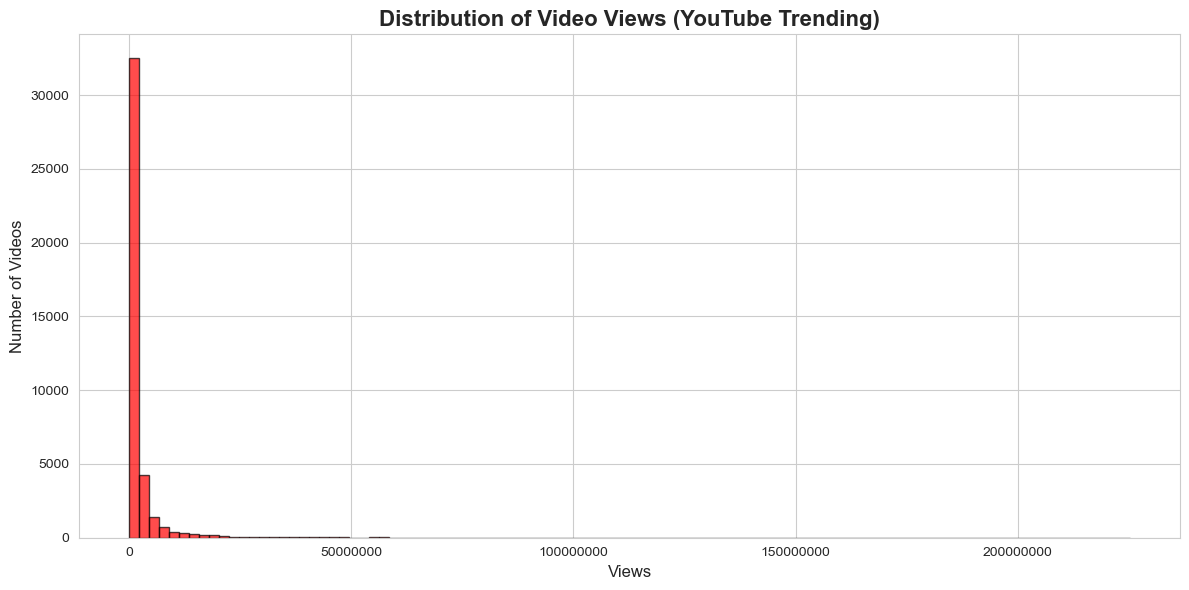

In [22]:
sns.set_style('whitegrid')
plt.figure(figsize=(12, 6))

# Histogram of views (use log scale because some videos have HUGE views)
plt.hist(df['views'], bins=100, color='#FF0000', edgecolor='black', alpha=0.7)
plt.xlabel('Views', fontsize=12)
plt.ylabel('Number of Videos', fontsize=12)
plt.title('Distribution of Video Views (YouTube Trending)', fontsize=16, fontweight='bold')
plt.ticklabel_format(style='plain', axis='x')
plt.tight_layout()
plt.show()

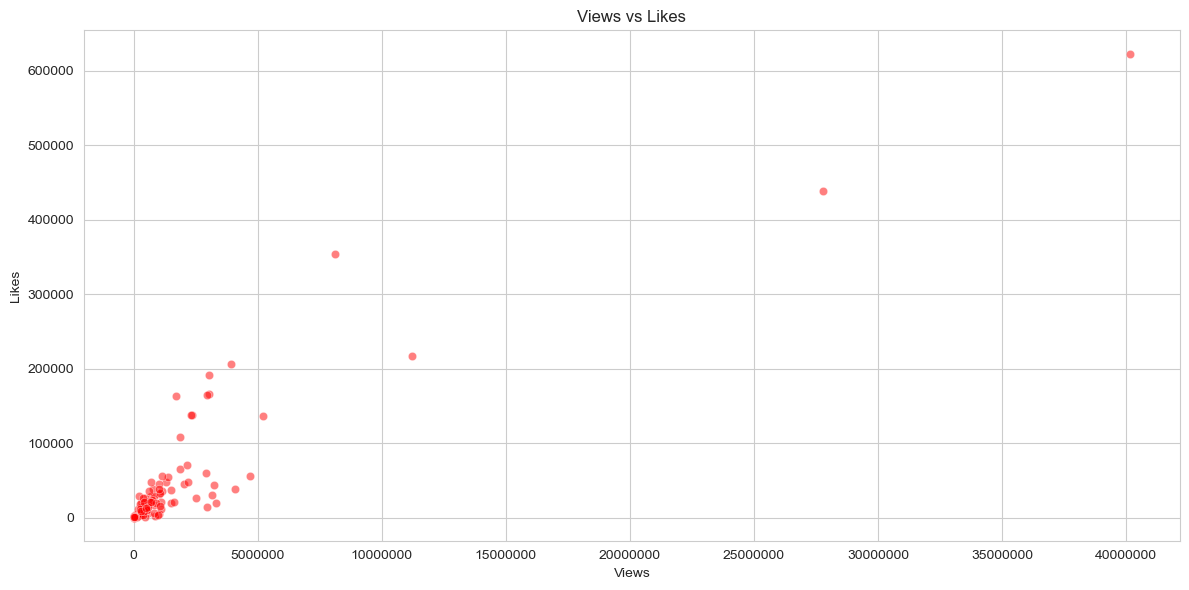

In [26]:
sns.set_style('whitegrid')
plt.figure(figsize=(12, 6))
sample=df.sample(100)
sns.scatterplot(data=sample, x='views',y='likes',alpha=0.5, color='red')
plt.xlabel('Views')
plt.ylabel('Likes')
plt.title('Views vs Likes')
plt.ticklabel_format(style='plain')
plt.tight_layout()

plt.show()

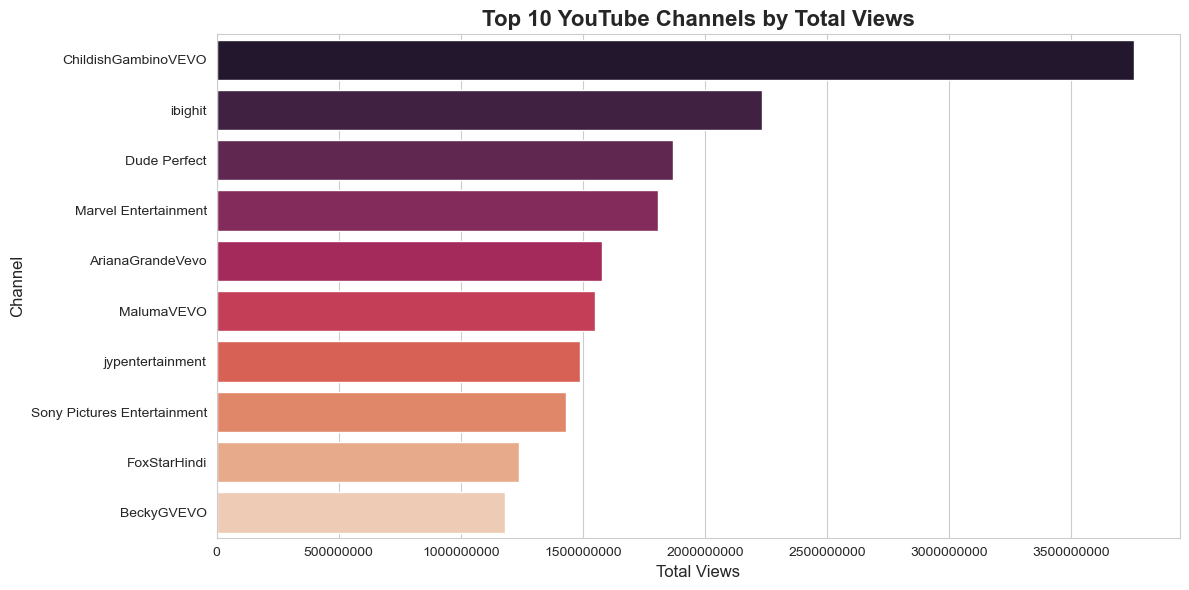

In [29]:
sns.set_style('whitegrid')
plt.figure(figsize=(12,6))


sns.barplot(x=top_channels.values,y=top_channels.index, palette='rocket')
plt.xlabel('Total Views', fontsize=12)
plt.ylabel('Channel', fontsize=12)
plt.title('Top 10 YouTube Channels by Total Views', fontsize=16, fontweight='bold')
plt.ticklabel_format(style='plain', axis='x')
plt.tight_layout()
plt.show()

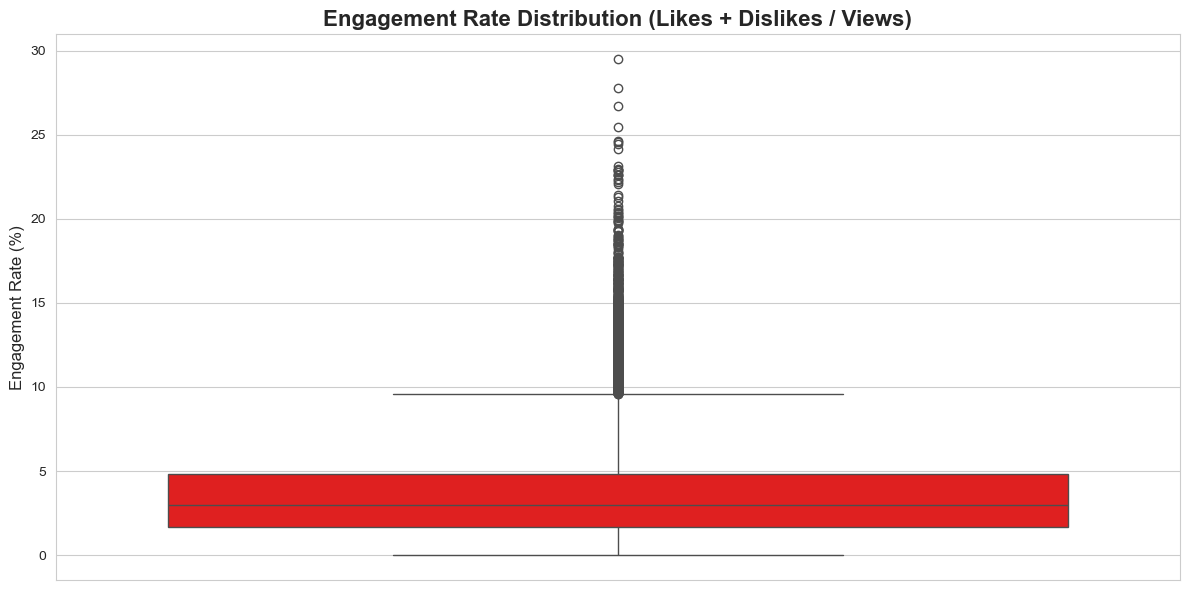


📊 Average engagement rate: 3.60%
📊 Median engagement rate: 3.00%


In [30]:
plt.figure(figsize=(12, 6))

sns.boxplot(data=df, y='engagement_rate', color='#FF0000')
plt.ylabel('Engagement Rate (%)', fontsize=12)
plt.title('Engagement Rate Distribution (Likes + Dislikes / Views)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\n📊 Average engagement rate: {df['engagement_rate'].mean():.2f}%")
print(f"📊 Median engagement rate: {df['engagement_rate'].median():.2f}%")

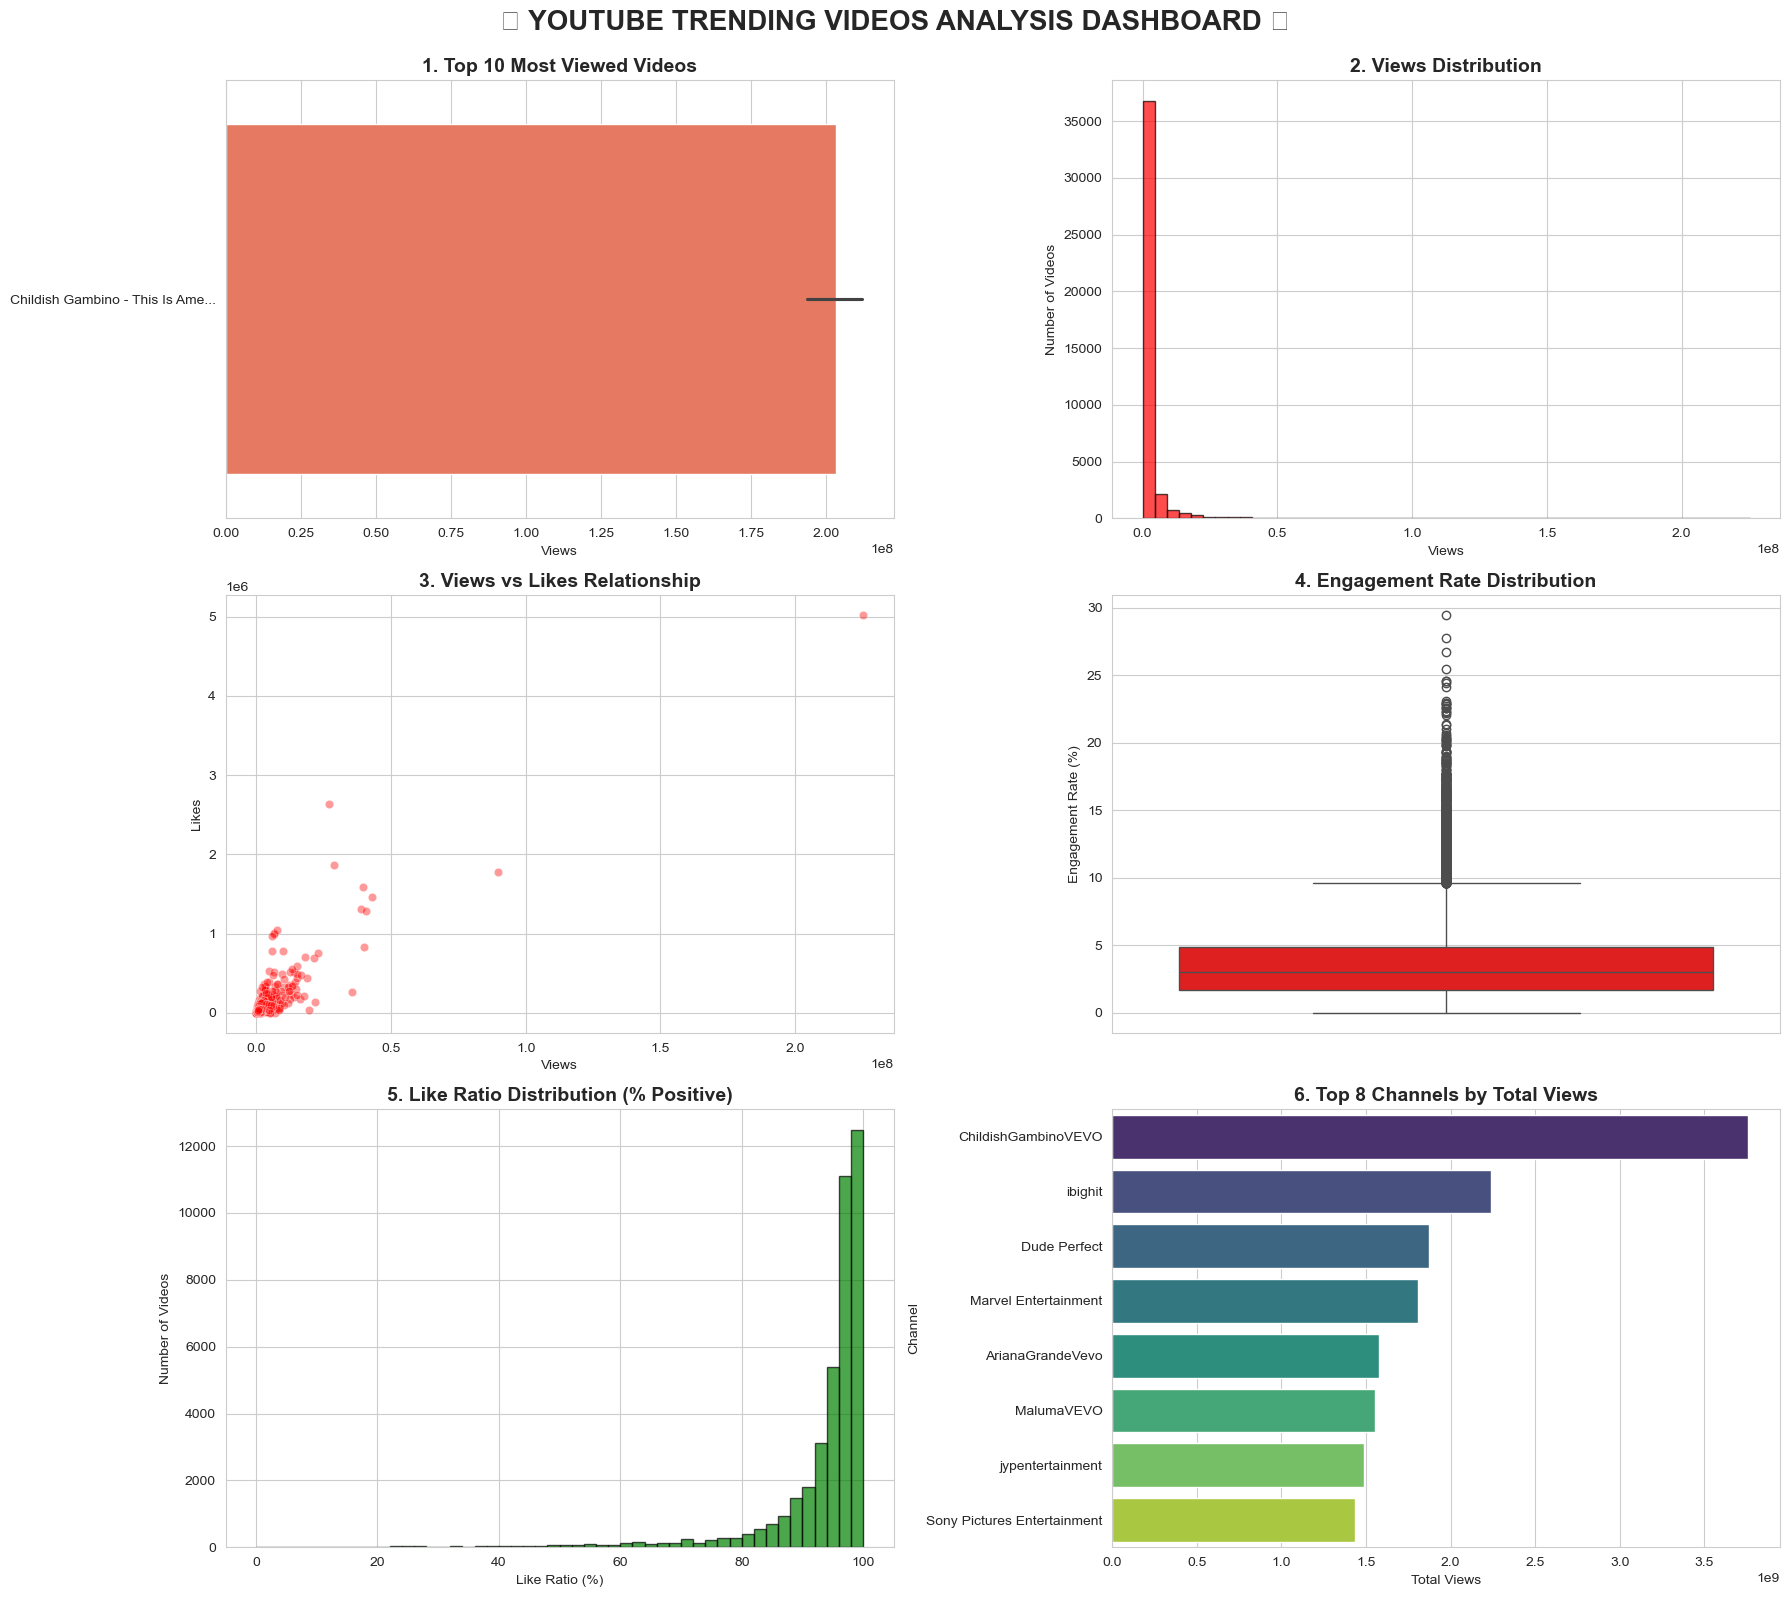

In [33]:
# Create a comprehensive YouTube Trending Dashboard

fig, axes = plt.subplots(3, 2, figsize=(18, 16))
sns.set_style('whitegrid')

# CHART 1: Top 10 Most Viewed Videos
top_10 = df.nlargest(10, 'views')
sns.barplot(data=top_10, y='title', x='views', palette='Reds_r', ax=axes[0, 0])
axes[0, 0].set_title('1. Top 10 Most Viewed Videos', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Views')
axes[0, 0].set_ylabel('')
axes[0, 0].set_yticklabels([title[:30] + '...' for title in top_10['title']])  # Shorten titles

# CHART 2: Views Distribution
axes[0, 1].hist(df['views'], bins=50, color='#FF0000', edgecolor='black', alpha=0.7)
axes[0, 1].set_title('2. Views Distribution', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Views')
axes[0, 1].set_ylabel('Number of Videos')

# CHART 3: Likes vs Views (Sample)
sample = df.sample(1000)
sns.scatterplot(data=sample, x='views', y='likes', alpha=0.4, color='#FF0000', ax=axes[1, 0])
axes[1, 0].set_title('3. Views vs Likes Relationship', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Views')
axes[1, 0].set_ylabel('Likes')

# CHART 4: Engagement Rate Box Plot
sns.boxplot(data=df, y='engagement_rate', color='#FF0000', ax=axes[1, 1])
axes[1, 1].set_title('4. Engagement Rate Distribution', fontsize=14, fontweight='bold')
axes[1, 1].set_ylabel('Engagement Rate (%)')

# CHART 5: Like Ratio Distribution
axes[2, 0].hist(df['like_ratio'], bins=50, color='green', edgecolor='black', alpha=0.7)
axes[2, 0].set_title('5. Like Ratio Distribution (% Positive)', fontsize=14, fontweight='bold')
axes[2, 0].set_xlabel('Like Ratio (%)')
axes[2, 0].set_ylabel('Number of Videos')

# CHART 6: Top Channels
top_channels = df.groupby('channel_title')['views'].sum().sort_values(ascending=False).head(8)
sns.barplot(x=top_channels.values, y=top_channels.index, palette='viridis', ax=axes[2, 1])
axes[2, 1].set_title('6. Top 8 Channels by Total Views', fontsize=14, fontweight='bold')
axes[2, 1].set_xlabel('Total Views')
axes[2, 1].set_ylabel('Channel')

# Overall title
fig.suptitle('📺 YOUTUBE TRENDING VIDEOS ANALYSIS DASHBOARD 📊', 
             fontsize=20, fontweight='bold', y=0.995)

plt.tight_layout()
plt.show()

In [35]:
print("="*80)
print("📝 MY YOUTUBE TRENDING ANALYSIS - KEY FINDINGS")
print("="*80)

print(f"\n📊 DATASET OVERVIEW:")
print(f"   - Total trending videos analyzed: {len(df):,}")
print(f"   - Total views across all videos: {df['views'].sum():,}")
print(f"   - Total likes: {df['likes'].sum():,}")

print(f"\n🏆 TOP PERFORMERS:")
print(f"   - Most viewed video: {df.nlargest(1, 'views')['title'].values[0][:50]}")
print(f"   - Views: {df['views'].max():,}")
print(f"   - Most liked video: {df.nlargest(1, 'likes')['title'].values[0][:50]}")
print(f"   - Likes: {df['likes'].max():,}")

print(f"\n📈 ENGAGEMENT INSIGHTS:")
print(f"   - Average engagement rate: {df['engagement_rate'].mean():.2f}%")
print(f"   - Average like ratio: {df['like_ratio'].mean():.1f}%")
print(f"   - This means {df['like_ratio'].mean():.1f}% of people who reacted, LIKED the video!")

print(f"\n💡 WHAT I DISCOVERED:")
print("   [Write 3-4 insights YOU found interesting from the data]")
print("   1. More No. of Likes is related to more omore of views ")
print("   2. Childish gambino topped in all sector")
print("   3. engagement rate should be more to increase your video popularity")

📝 MY YOUTUBE TRENDING ANALYSIS - KEY FINDINGS

📊 DATASET OVERVIEW:
   - Total trending videos analyzed: 40,949
   - Total views across all videos: 96,671,770,152
   - Total likes: 3,041,147,198

🏆 TOP PERFORMERS:
   - Most viewed video: Childish Gambino - This Is America (Official Video
   - Views: 225,211,923
   - Most liked video: BTS (ë°©íìëë¨) 'FAKE LOVE' Official MV
   - Likes: 5,613,827

📈 ENGAGEMENT INSIGHTS:
   - Average engagement rate: 3.60%
   - Average like ratio: 93.3%
   - This means 93.3% of people who reacted, LIKED the video!

💡 WHAT I DISCOVERED:
   [Write 3-4 insights YOU found interesting from the data]
   1. More No. of Likes is related to more omore of views 
   2. Childish gambino topped in all sector
   3. engagement rate should be more to increase your video popularity
